In [1]:
from model_ranking import (
    load_h5,
    get_roi_slice,
    get_random_colors,
)
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from plantseg.functionals.dataprocessing.labelprocessing import set_background_to_value, set_biggest_instance_to_zero, relabel_segmentation
from plantseg.functionals.segmentation import dt_watershed, gasp

INFO: P [MainThread] 2026-07-23 10:11:20,018 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
Fw_gt_path = "/scratch/talks/data/FlyWing/GT/test/per03.h5"
label_key = "volumes/labels/expanded_cells_with_ignore"
raw_key = "volumes/raw"

fw_gt = load_h5(Fw_gt_path, label_key)
fw_raw = load_h5(Fw_gt_path, raw_key)
fw_ignore = load_h5(Fw_gt_path, "volumes/labels/ignore")
print(fw_gt.shape, fw_raw.shape)

(160, 639, 765) (160, 639, 765)


# PNAS to FlyWing

In [13]:
pred_path_NA = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/PNAS_to_FlyWing_gap/consistency/P_fullslice/p_model_UNet1/norm_50_950/none/predictions/per03_predictions.h5"
preds_NA = load_h5(pred_path_NA, "predictions")
segs_NA = load_h5(pred_path_NA, "segmentation")
MAP_score_NA = load_h5(pred_path_NA, "MAP_05_095")
patch_indexes = load_h5(pred_path_NA, "patch_index")
print(preds_NA.shape, MAP_score_NA.shape)

(160, 1, 1, 639, 765) (160,)


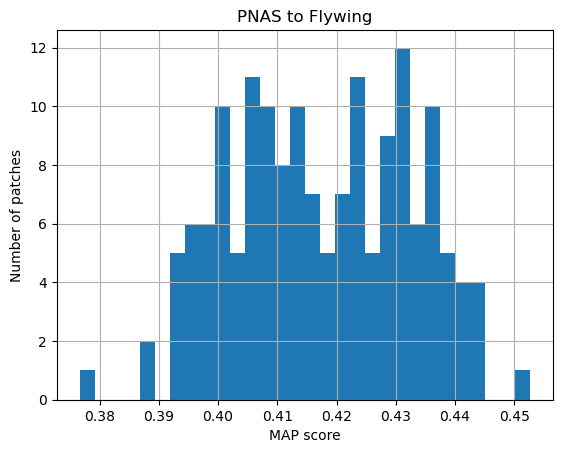

In [14]:
plt.hist(MAP_score_NA, bins=30)
plt.xlabel("MAP score")
plt.ylabel("Number of patches")
plt.title("PNAS to Flywing")
plt.grid()
plt.show()

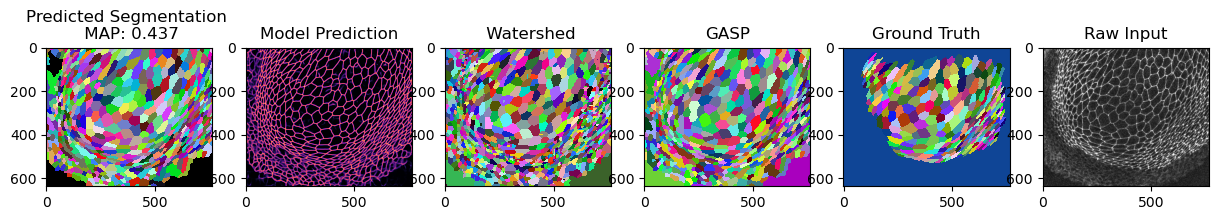

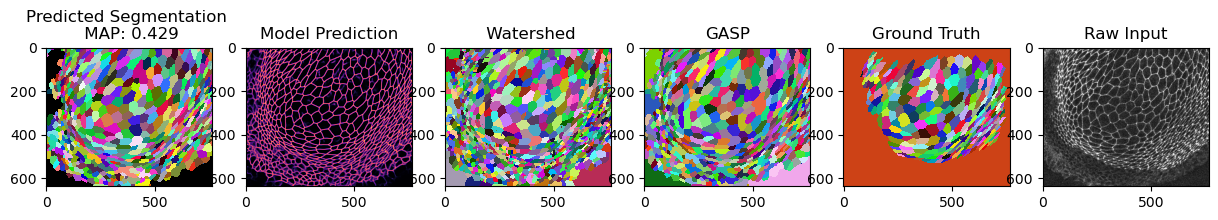

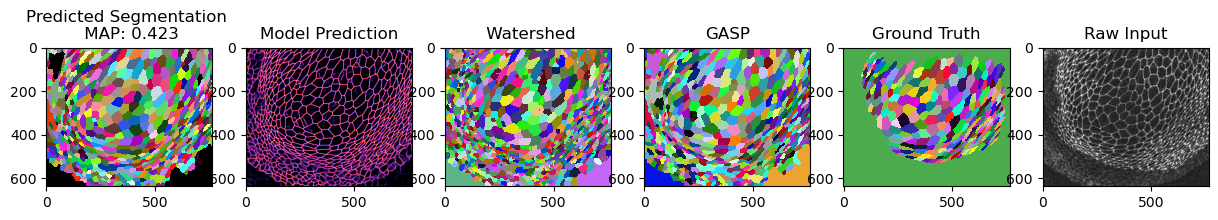

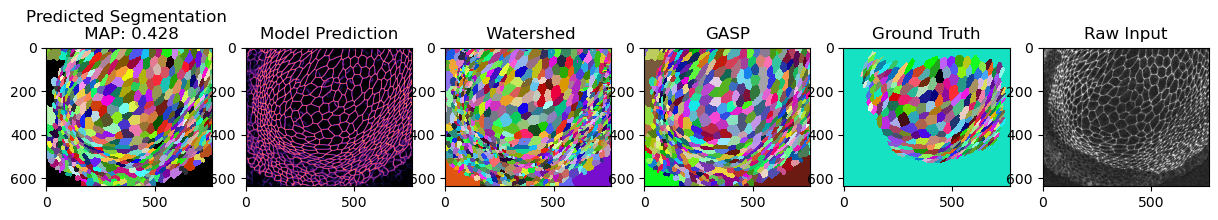

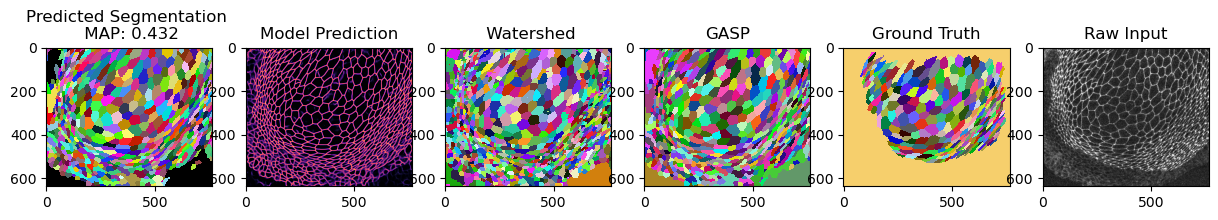

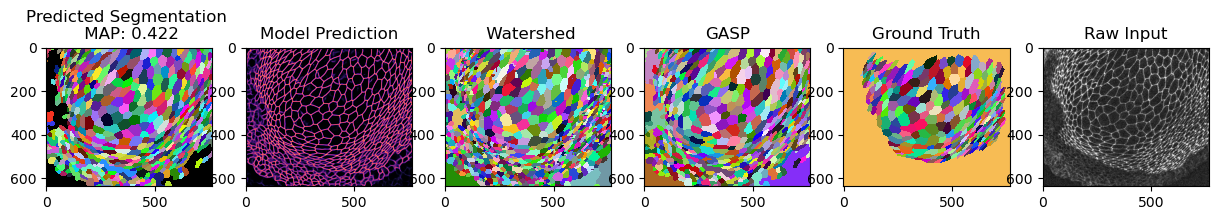

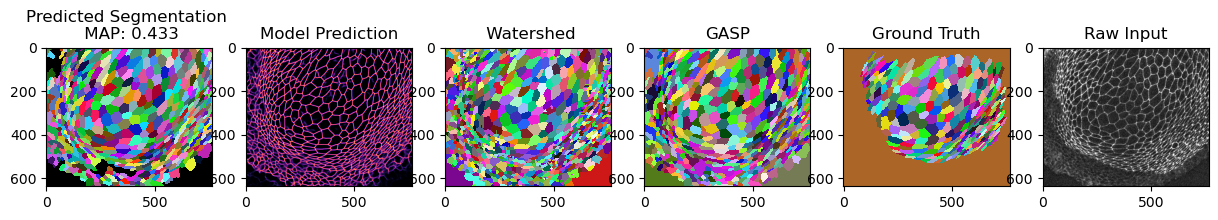

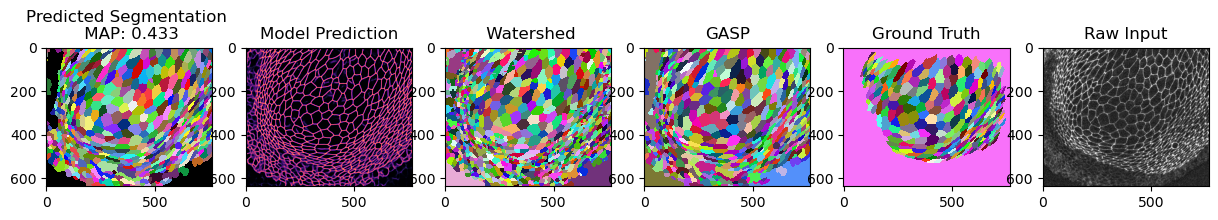

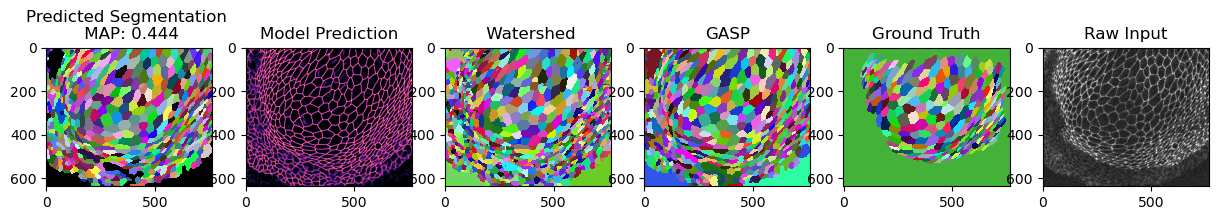

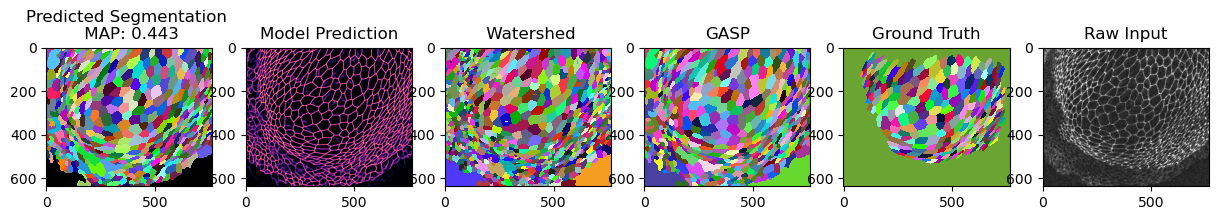

In [15]:
for i in range(80, 90):
    patch_roi = get_roi_slice(patch_indexes[i])
    pred_wt = dt_watershed(preds_NA[i].squeeze(), threshold=0.5, stacked=False, min_size=5)
    gasp_pred = gasp(preds_NA[i].squeeze(), pred_wt, post_minsize=50, beta=0.5)
    _, axs = plt.subplots(1, 6, figsize=(15, 5))
    axs[0].imshow(segs_NA[i].squeeze(), cmap=get_random_colors(segs_NA[i]), interpolation='nearest')
    axs[0].set_title(f"Predicted Segmentation \n MAP: {MAP_score_NA[i]:.3f}")
    axs[1].imshow(preds_NA[i].squeeze(), cmap="magma")
    axs[1].set_title(f"Model Prediction")
    axs[2].imshow(pred_wt, cmap=get_random_colors(pred_wt), interpolation='nearest')
    axs[2].set_title(f" Watershed")
    axs[3].imshow(gasp_pred, cmap=get_random_colors(gasp_pred), interpolation='nearest')
    axs[3].set_title(f"GASP")
    axs[4].imshow(fw_gt[patch_roi].squeeze(), cmap=get_random_colors(fw_gt[patch_roi]), interpolation='nearest')
    axs[4].set_title(f"Ground Truth")
    axs[5].imshow(fw_raw[patch_roi].squeeze(), cmap="gray")
    axs[5].set_title(f"Raw Input")
    plt.show()

# Ovules to FlyWing

In [16]:
pred_path_NA = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/Ovules_to_FlyWing_gap/consistency/P_fullslice/ov_model_UNet1/norm_50_950/none/predictions/per03_predictions.h5"
preds_NA = load_h5(pred_path_NA, "predictions")
segs_NA = load_h5(pred_path_NA, "segmentation")
MAP_score_NA = load_h5(pred_path_NA, "MAP_05_095")
patch_indexes = load_h5(pred_path_NA, "patch_index")
print(preds_NA.shape, MAP_score_NA.shape)

(160, 1, 1, 639, 765) (160,)


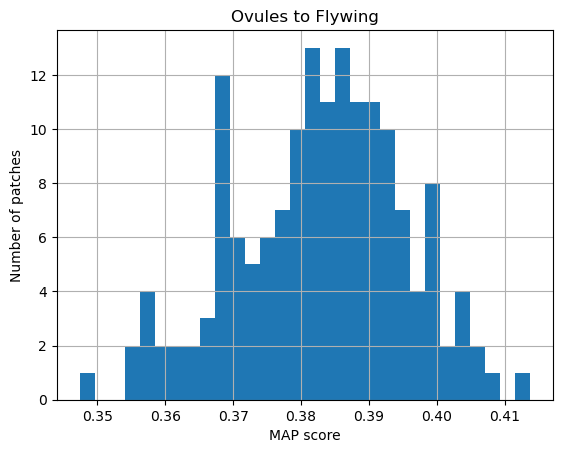

In [17]:
plt.hist(MAP_score_NA, bins=30)
plt.xlabel("MAP score")
plt.ylabel("Number of patches")
plt.title("Ovules to Flywing")
plt.grid()
plt.show()

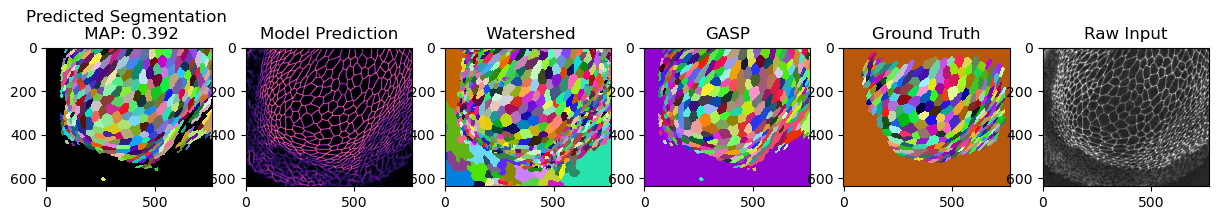

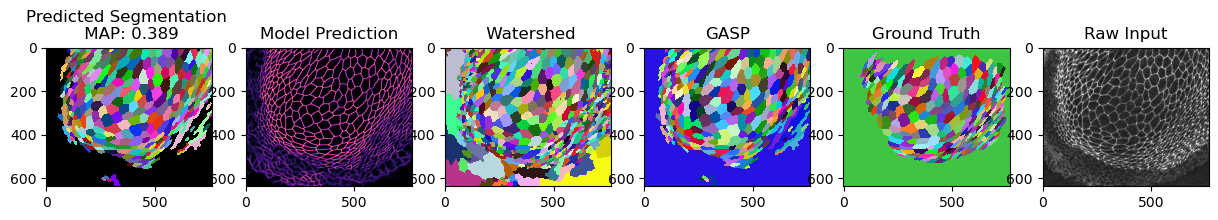

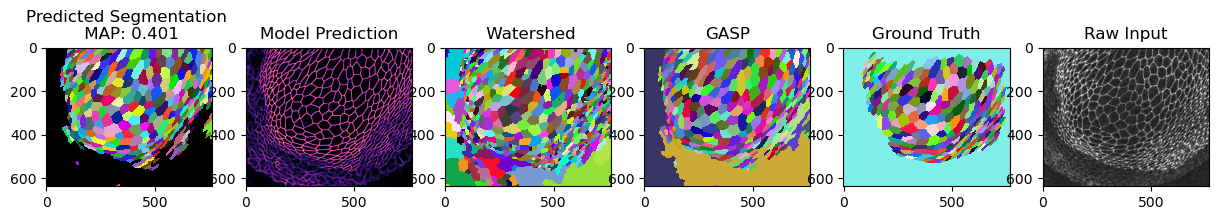

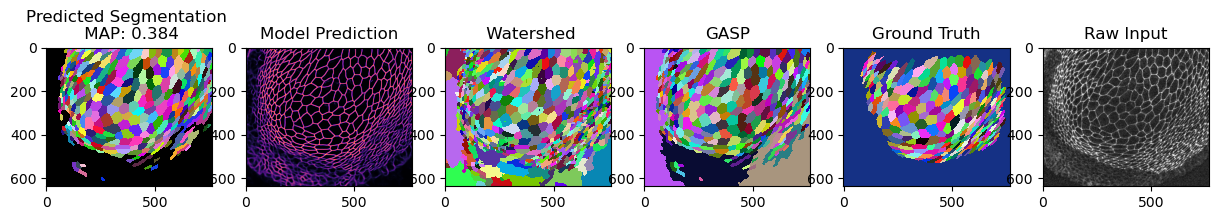

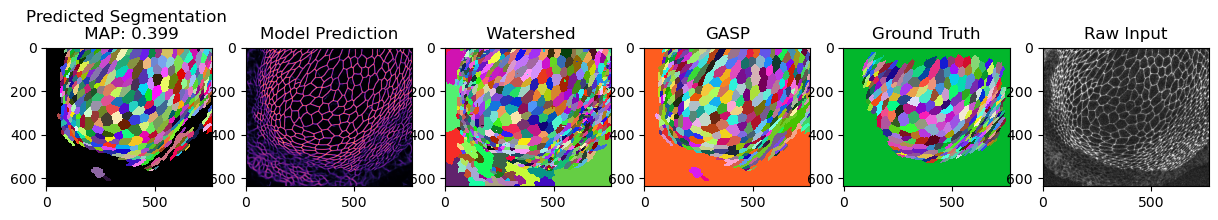

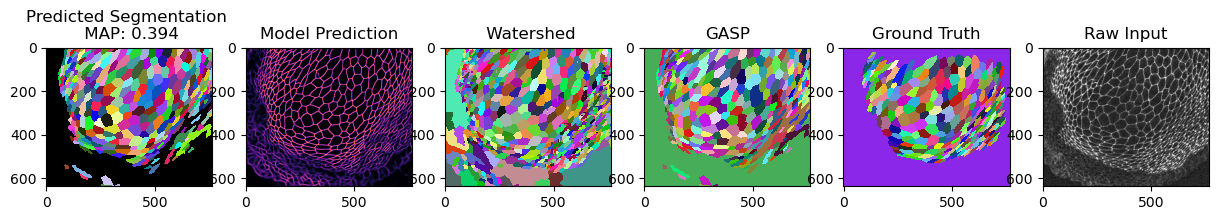

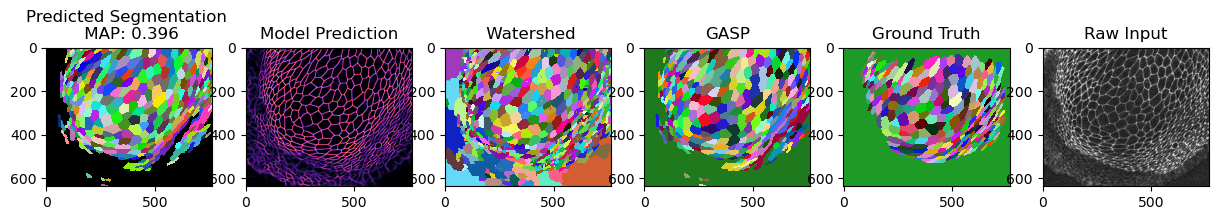

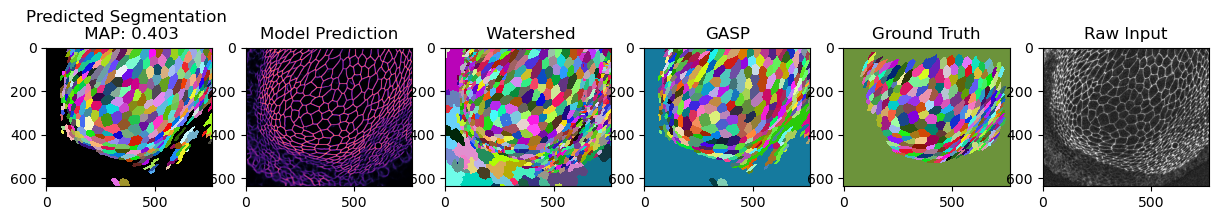

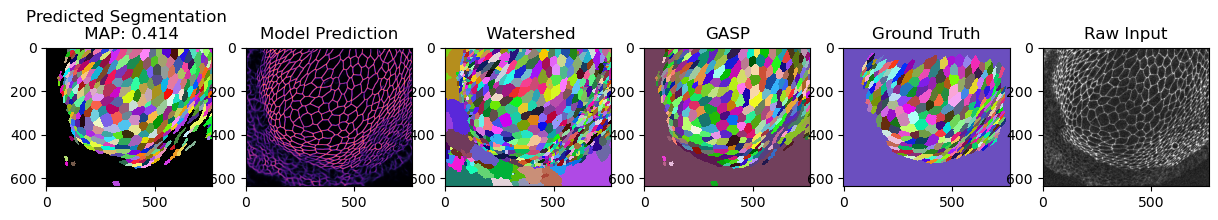

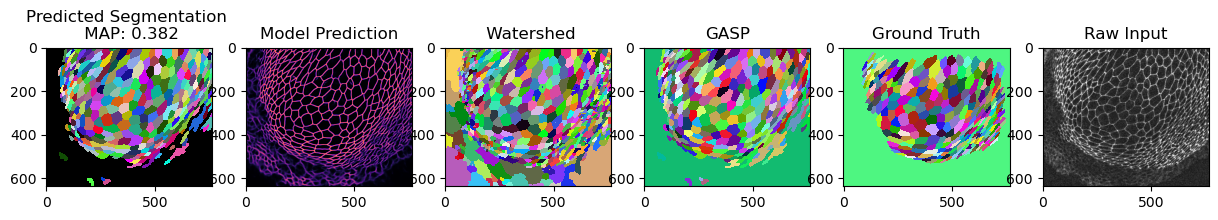

In [18]:
for i in range(80, 90):
    patch_roi = get_roi_slice(patch_indexes[i])
    pred_wt = dt_watershed(preds_NA[i].squeeze(), threshold=0.5, stacked=False, min_size=5)
    gasp_pred = gasp(preds_NA[i].squeeze(), pred_wt, post_minsize=50, beta=0.5)
    _, axs = plt.subplots(1, 6, figsize=(15, 5))
    axs[0].imshow(segs_NA[i].squeeze(), cmap=get_random_colors(segs_NA[i]), interpolation='nearest')
    axs[0].set_title(f"Predicted Segmentation \n MAP: {MAP_score_NA[i]:.3f}")
    axs[1].imshow(preds_NA[i].squeeze(), cmap="magma")
    axs[1].set_title(f"Model Prediction")
    axs[2].imshow(pred_wt, cmap=get_random_colors(pred_wt), interpolation='nearest')
    axs[2].set_title(f" Watershed")
    axs[3].imshow(gasp_pred, cmap=get_random_colors(gasp_pred), interpolation='nearest')
    axs[3].set_title(f"GASP")
    axs[4].imshow(fw_gt[patch_roi].squeeze(), cmap=get_random_colors(fw_gt[patch_roi]), interpolation='nearest')
    axs[4].set_title(f"Ground Truth")
    axs[5].imshow(fw_raw[patch_roi].squeeze(), cmap="gray")
    axs[5].set_title(f"Raw Input")
    plt.show()

In [24]:
fw_ignore.shape
ignore_mask = fw_ignore[84] == -1
print(ignore_mask.shape, ignore_mask.sum())

(639, 765) 0


In [27]:
np.unique(fw_ignore[84], return_counts=True)

(array([0, 1], dtype=uint8), array([259175, 229660]))

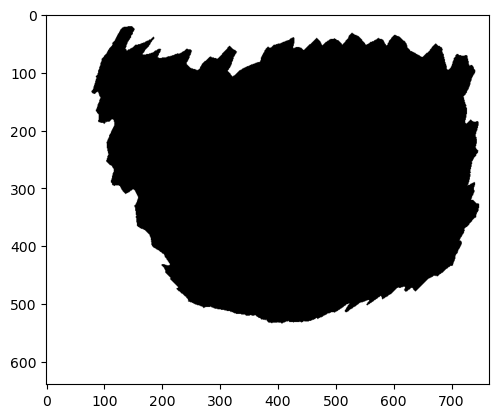

In [26]:
plt.imshow(fw_ignore[84], cmap="gray")

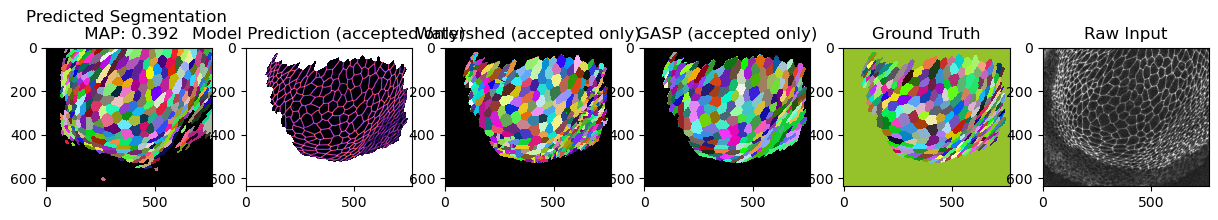

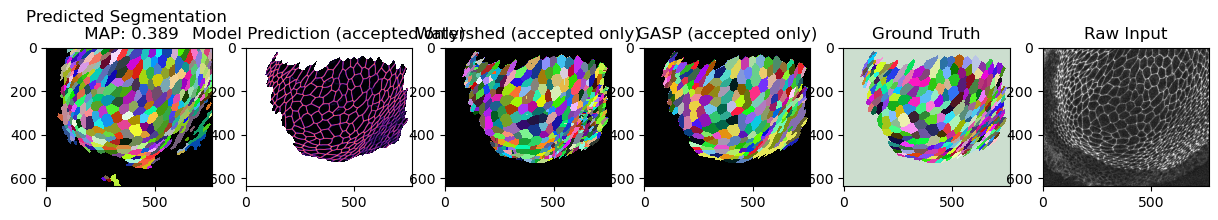

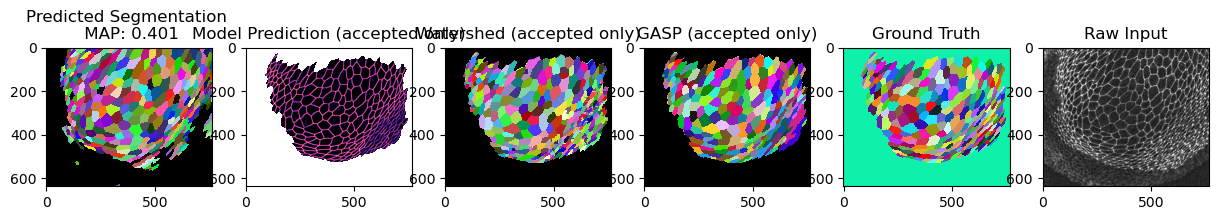

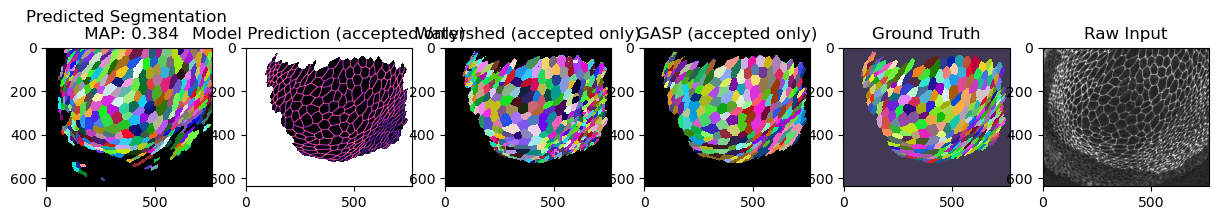

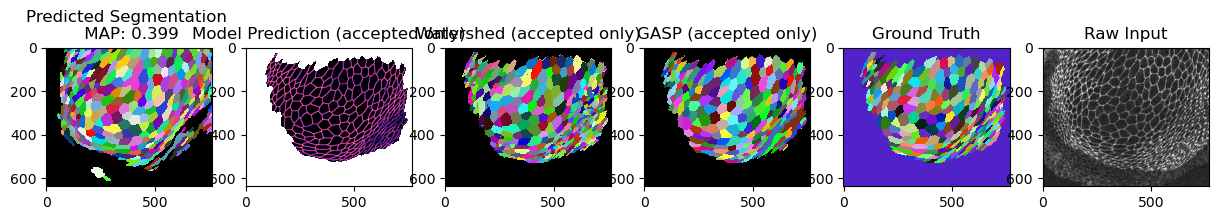

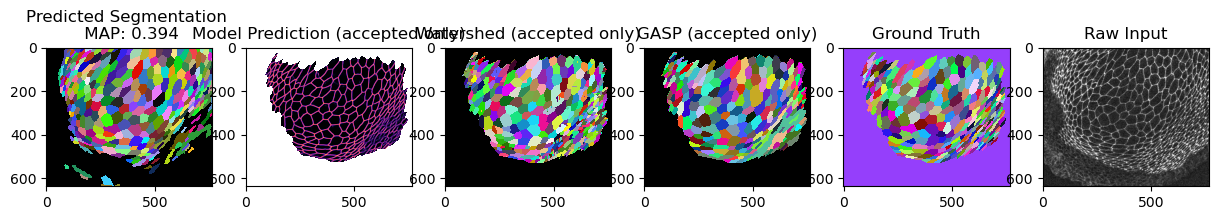

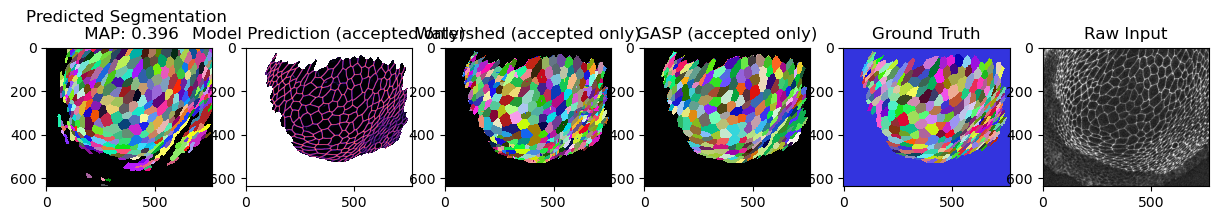

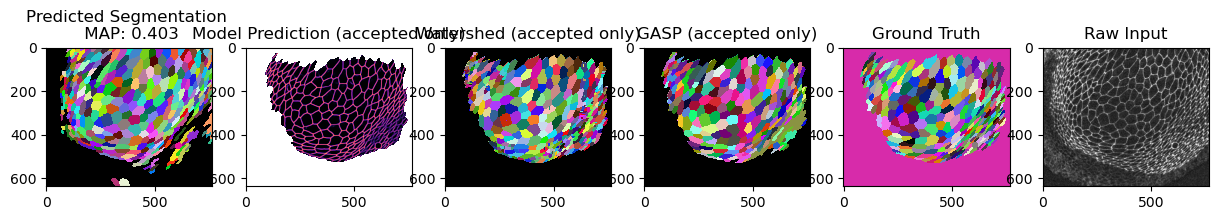

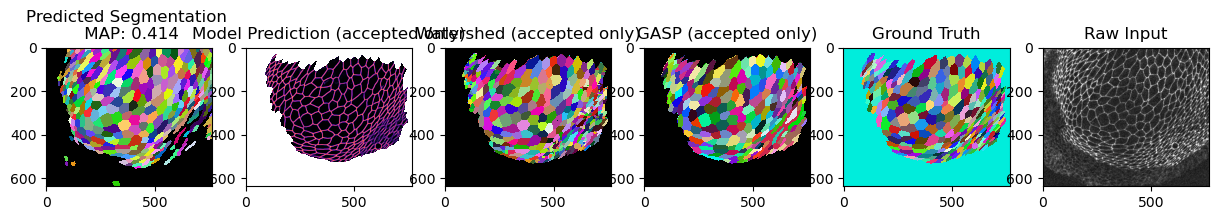

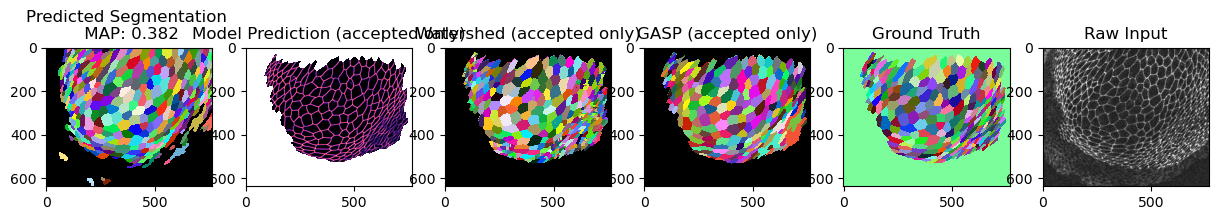

In [29]:
# ...existing code...
for i in range(80, 90):
    patch_roi = get_roi_slice(patch_indexes[i])

    pred = preds_NA[i].squeeze()
    pred_wt = dt_watershed(pred, threshold=0.5, stacked=False, min_size=5)
    gasp_pred = gasp(pred, pred_wt, post_minsize=50, beta=0.5)

    # ignore mask: 1 = ignore, 0 = accept
    ignore_patch = fw_ignore[patch_roi].squeeze()
    accept_mask = (ignore_patch == 0)

    # Apply mask only to requested prediction views
    pred_plot = np.where(accept_mask, pred, np.nan)      # continuous -> hide ignored with NaN
    pred_wt_plot = np.where(accept_mask, pred_wt, 0)     # labels -> set ignored to background
    gasp_plot = np.where(accept_mask, gasp_pred, 0)      # labels -> set ignored to background

    _, axs = plt.subplots(1, 6, figsize=(15, 5))
    axs[0].imshow(segs_NA[i].squeeze(), cmap=get_random_colors(segs_NA[i]), interpolation="nearest")
    axs[0].set_title(f"Predicted Segmentation \n MAP: {MAP_score_NA[i]:.3f}")

    pred_cmap = plt.cm.magma.copy()
    pred_cmap.set_bad(alpha=0.0)  # transparent where NaN
    axs[1].imshow(pred_plot, cmap=pred_cmap)
    axs[1].set_title("Model Prediction (accepted only)")

    axs[2].imshow(pred_wt_plot, cmap=get_random_colors(pred_wt_plot), interpolation="nearest")
    axs[2].set_title("Watershed (accepted only)")

    axs[3].imshow(gasp_plot, cmap=get_random_colors(gasp_plot), interpolation="nearest")
    axs[3].set_title("GASP (accepted only)")

    axs[4].imshow(fw_gt[patch_roi].squeeze(), cmap=get_random_colors(fw_gt[patch_roi]), interpolation="nearest")
    axs[4].set_title("Ground Truth")

    axs[5].imshow(fw_raw[patch_roi].squeeze(), cmap="gray")
    axs[5].set_title("Raw Input")
    plt.show()
# ...existing code...